# QPSK Comms + STEAM Imaging + 3D Depth: One Forward Model, Three SBIR Proposals
### Full pipeline demo tying together dgs/gs_core.py, dgs/steam_imaging.py, dgs/steam_3d_depth_encoding.py

**The shared physics:** every section below disperses a field through the SAME
transfer function `H(f) = exp(i*pi*D*f^2)` (Griffiths Ch 9 GVD, Taylor-expanded
k(omega)) and recovers phase from intensity-only measurements via Gerchberg-
Saxton (GS). What differs is what's encoded in that phase and what the two
measurement planes are used for:

| Section | Encodes            | SBIR proposal              | Module |
|---------|---------------------|-----------------------------|--------|
| §2      | comms symbols (phase)| P7 Photonic AI Receiver    | dgs/gs_core.py |
| §3      | cell image (x,y)     | P2 STEAM Microscopy        | dgs/steam_imaging.py |
| §4      | + depth (z)          | P9 3D STEAM Camera (new)   | dgs/steam_3d_depth_encoding.py |

This notebook does NOT claim these three are one combined system in hardware --
each is its own SBIR proposal with its own agency/budget in dgs/sbir_portfolio.py.
The point is to show, runnable, that they share one forward model and one
inverse algorithm, which is exactly why the repo can support all three.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import gs_core
from dgs import steam_imaging
from dgs import steam_3d_depth_encoding as depth3d

print("Setup complete. numpy", np.__version__)


Setup complete. numpy 2.4.4


## §2. QPSK Comms Symbol Recovery (P7: Photonic AI Receiver)

**Use case:** an LO-free coherent optical receiver. The transmitted phase IS
the data (QPSK: 2 bits/symbol on the unit circle). STEAM time-stretches the
received signal; GS recovers phase from two dispersed intensity measurements
without ever needing a local-oscillator laser.

`dgs.gs_core.make_measurements('QPSK', ...)` generates the synthetic signal
and its two dispersed intensity measurements I1, I2; `retrieve_phase` runs GS.


QPSK phase recovery: correlation = 0.8053 after 50 GS iterations
Final RMS amplitude error: 4.68e-02


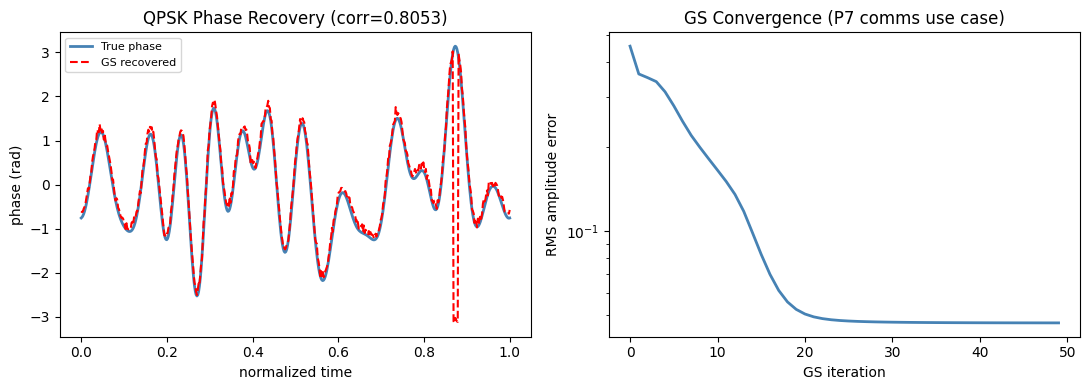

In [2]:
# QPSK signal generation + GS phase recovery
meas = gs_core.make_measurements(modulation='QPSK', n_symbols=64, sps=8,
                                  D1=-5000.0, D2=-5750.0, snr_db=25.0, rng_seed=0)

phi_recovered, errors = gs_core.retrieve_phase(
    meas['I1'], meas['I2'], meas['D1'], meas['D2'],
    n_iter=50, unit_amplitude=meas['unit_amplitude'])

corr = np.corrcoef(phi_recovered, meas['phi_true'])[0, 1]
print(f"QPSK phase recovery: correlation = {corr:.4f} after 50 GS iterations")
print(f"Final RMS amplitude error: {errors[-1]:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(meas['t'], meas['phi_true'], 'steelblue', lw=2, label='True phase')
axes[0].plot(meas['t'], phi_recovered, 'red', lw=1.5, ls='--', label='GS recovered')
axes[0].set_xlabel('normalized time'); axes[0].set_ylabel('phase (rad)')
axes[0].set_title(f'QPSK Phase Recovery (corr={corr:.4f})')
axes[0].legend(fontsize=8)

axes[1].semilogy(errors, 'steelblue', lw=2)
axes[1].set_xlabel('GS iteration'); axes[1].set_ylabel('RMS amplitude error')
axes[1].set_title('GS Convergence (P7 comms use case)')

plt.tight_layout()
plt.savefig('qpsk_gs_recovery.png', dpi=100, bbox_inches='tight')
plt.show()


## §3. 2D STEAM Cell Imaging (P2: STEAM Microscopy)

**Use case:** a broadband pulse illuminates a cell; each wavelength picks up
one pixel's phase via the cell's local refractive index. `time_stretch_pulse`
applies the SAME H(f) to map wavelength -> time; the ADC sees only intensity.
We then reuse `gs_core.retrieve_phase` (same algorithm as §2) at two
dispersions to recover the cell's phase image.


2D STEAM image recovery: correlation = 0.9912


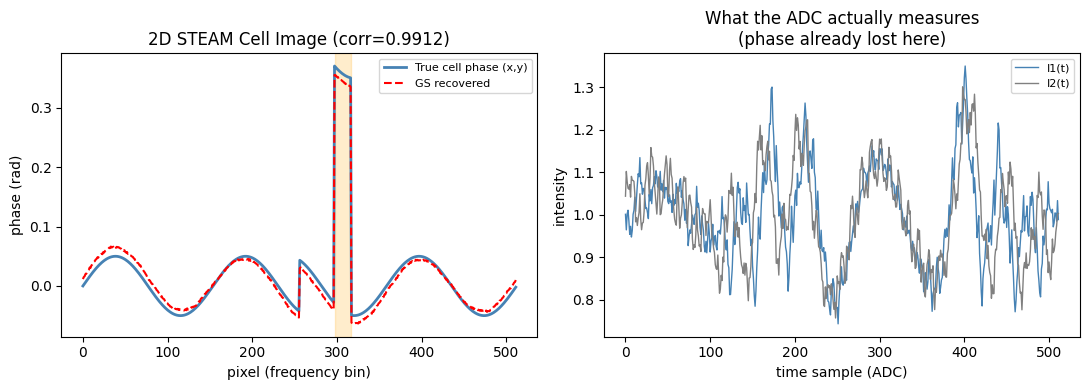

In [3]:
# Synthetic 'cell' phase object: smooth background + a localized bump
N = 512
f_arr = np.fft.fftfreq(N)

phi_cell = 0.05 * np.sin(2 * np.pi * f_arr / 0.3)
bump_center, bump_width = int(0.6 * N), int(0.02 * N)
phi_cell[bump_center - bump_width:bump_center + bump_width] += 0.4   # feature to image
E_cell = np.exp(1j * phi_cell)   # unit-amplitude phase object

D1_img, D2_img = -5000.0, -5750.0
out1 = steam_imaging.time_stretch_pulse(E_cell, f_arr, D1_img)
out2 = steam_imaging.time_stretch_pulse(E_cell, f_arr, D2_img)
I1_img, I2_img = out1['I_out'], out2['I_out']

phi_img_recovered, errors_img = gs_core.retrieve_phase(
    I1_img, I2_img, D1_img, D2_img, n_iter=50, unit_amplitude=True)

# align global phase offset before comparing
offset = np.mean(phi_img_recovered - phi_cell)
phi_img_aligned = phi_img_recovered - offset
corr_img = np.corrcoef(phi_img_aligned, phi_cell)[0, 1]
print(f"2D STEAM image recovery: correlation = {corr_img:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(phi_cell, 'steelblue', lw=2, label='True cell phase (x,y)')
axes[0].plot(phi_img_aligned, 'red', lw=1.5, ls='--', label='GS recovered')
axes[0].axvspan(bump_center - bump_width, bump_center + bump_width, alpha=0.2, color='orange')
axes[0].set_xlabel('pixel (frequency bin)'); axes[0].set_ylabel('phase (rad)')
axes[0].set_title(f'2D STEAM Cell Image (corr={corr_img:.4f})')
axes[0].legend(fontsize=8)

axes[1].plot(I1_img, 'steelblue', lw=1, label='I1(t)')
axes[1].plot(I2_img, 'gray', lw=1, label='I2(t)')
axes[1].set_xlabel('time sample (ADC)'); axes[1].set_ylabel('intensity')
axes[1].set_title('What the ADC actually measures\n(phase already lost here)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('steam_2d_image_recovery.png', dpi=100, bbox_inches='tight')
plt.show()


## §4. Depth-Resolved (3D) STEAM Camera (P9: new proposal, this session)

**Status, stated honestly (matches `dgs/steam_3d_depth_encoding.py`'s own
module docstring):** standard STEAM is 2D. No published "3D STEAM" with depth
turned up in a literature search. What follows is a PROPOSED combination of
two independently real techniques -- Goda's grating+VIPA 2D encoding (§3
above) and chromatic-confocal depth sensing -- not a claim that this exists
in the literature. This is exactly the P9 proposal wired into
`dgs/sbir_portfolio.py` this session.

**The trick:** put the xy-image band and a z-depth band in two non-overlapping
wavelength sub-ranges of the same pulse. Both go through the same dispersive
fiber, so each lands in its own non-overlapping TIME window on one ADC
capture -- demultiplexed by time, not by a second detector.


spectral budget: 60.0 nm -> 40.0 nm (xy) + 20.0 nm (z)
xy time window:   32.0 ns
z time window:    16.0 ns
total frame time: 48.0 ns  ->  20.8 Mfps
depth resolution: 0.100 um
depth range:      40.0 um  (order of a single cell)


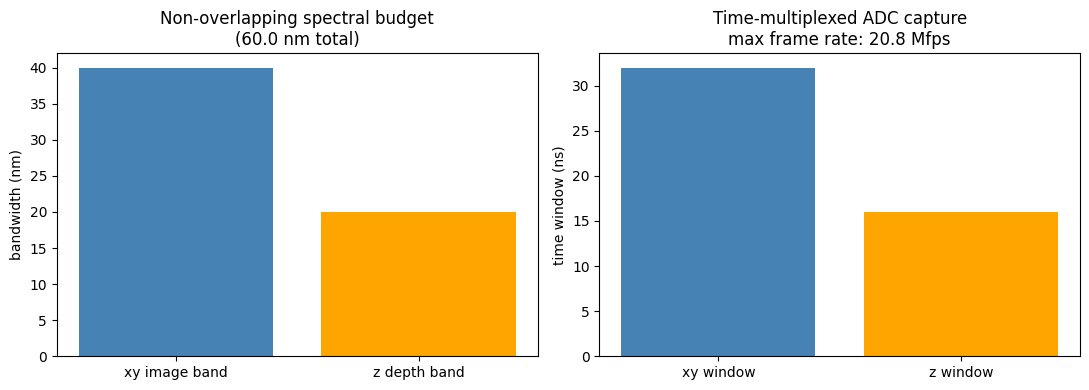

sanity check: wavelength shifted for z=10um -> recovered z = 10.000 um


In [4]:
# Spectral budget: split one broadband pulse into xy-image + z-depth bands
total_bandwidth_nm = 60.0
xy_band_nm = 40.0
D_ps_per_nm = 800.0
axial_dispersion_nm_per_um = 0.5     # representative chromatic-confocal lens
spectral_resolution_nm = 0.05        # representative VIPA/grating resolution

xy_band, z_band = depth3d.split_spectral_budget(total_bandwidth_nm, xy_band_nm)
timing = depth3d.frame_time_budget(D_ps_per_nm, xy_band, z_band)
z_res = depth3d.depth_resolution_um(spectral_resolution_nm, axial_dispersion_nm_per_um)
z_range = depth3d.depth_range_um(z_band, axial_dispersion_nm_per_um)

print(f"spectral budget: {total_bandwidth_nm} nm -> {xy_band} nm (xy) + {z_band} nm (z)")
print(f"xy time window:   {timing['T_xy_ns']:.1f} ns")
print(f"z time window:    {timing['T_z_ns']:.1f} ns")
print(f"total frame time: {timing['T_total_ns']:.1f} ns  ->  {timing['max_frame_rate_hz']/1e6:.1f} Mfps")
print(f"depth resolution: {z_res:.3f} um")
print(f"depth range:      {z_range:.1f} um  (order of a single cell)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['xy image band', 'z depth band'], [xy_band, z_band], color=['steelblue', 'orange'])
axes[0].set_ylabel('bandwidth (nm)')
axes[0].set_title(f'Non-overlapping spectral budget\n({total_bandwidth_nm} nm total)')

axes[1].bar(['xy window', 'z window'], [timing['T_xy_ns'], timing['T_z_ns']], color=['steelblue', 'orange'])
axes[1].set_ylabel('time window (ns)')
axes[1].set_title(f'Time-multiplexed ADC capture\nmax frame rate: {timing["max_frame_rate_hz"]/1e6:.1f} Mfps')

plt.tight_layout()
plt.savefig('steam_3d_depth_budget.png', dpi=100, bbox_inches='tight')
plt.show()

# Sanity check: chromatic_confocal_depth_um is the correct inverse relation
lambda0 = 1550.0
test_wavelength = lambda0 + axial_dispersion_nm_per_um * 10.0
z_check = depth3d.chromatic_confocal_depth_um(test_wavelength, lambda0, axial_dispersion_nm_per_um)
print(f"sanity check: wavelength shifted for z=10um -> recovered z = {z_check:.3f} um")


## §5. Summary: One Forward Model, Three Proposals

```
H(f) = exp(i*pi*D*f^2)          <- Griffiths Ch 9 GVD, same in all 3 sections
    |
    +-- §2 QPSK phase = comms data      -> P7 Photonic AI Receiver ($1.75M Phase II)
    +-- §3 phase = cell image (x,y)     -> P2 STEAM Microscopy ($275K Phase I)
    +-- §4 phase + time-mux z band      -> P9 3D STEAM Camera ($275K Phase I, new)
```

**What this notebook did NOT do:** claim §2-§4 are one combined hardware
system. They are three separate SBIR proposals in `dgs/sbir_portfolio.py`
that happen to share a forward model and a GS inverse algorithm -- that
shared code is why building all three is tractable from one repo, not
evidence that a single device does comms, imaging, and depth-sensing at once.

**Next step:** `py -3.13 -c "from dgs.sbir_portfolio import demo; demo()"`
for the full portfolio including P9's budget/milestones/honesty notes.
